In [55]:
import pandas
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.impute import SimpleImputer
from matplotlib.colors import LogNorm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline 
from imblearn.combine import SMOTEENN
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_curve, auc, precision_score, recall_score, f1_score, precision_recall_fscore_support, ConfusionMatrixDisplay

In [56]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m' # orange on some systems
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m' # called to return to standard terminal text color

def colored_text(color, txt):
    return color + str(txt) + RESET

In [57]:
# Importing all cleaned datasets
df_usagers = pandas.read_csv("df_usagers_clean.csv")
df_caract = pandas.read_csv("df_caract_clean.csv")
df_lieux = pandas.read_csv("df_lieux_clean.csv")
df_vehicules = pandas.read_csv("df_vehicules_clean.csv")

In [58]:
df_main = df_usagers.merge(df_vehicules, on = ['Num_Acc', 'id_vehicule'], how='left')
df_main = df_main.merge(df_caract, on = ['Num_Acc'], how = 'left')
df_main = df_main.merge(df_lieux, on = ['Num_Acc'], how = 'left')

In [59]:
df_main

,Num_Acc,id_vehicule,place,catu,grav,sexe,trajet,locp,actp,etatp,...,catr,circ,nbv,vosp,prof,plan,surf,infra,situ,vma
0,201900000001,138306524,2,2,4,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,201900000001,138306524,1,1,4,2,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,201900000001,138306525,1,1,1,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,201900000002,138306523,1,1,4,2,NaN,NaN,NaN,NaN,...,1.0,1.0,2.0,0.0,4.0,2.0,1.0,0.0,1.0,70.0
4,201900000003,138306520,1,1,1,1,NaN,NaN,0.0,NaN,...,1.0,3.0,8.0,0.0,1.0,3.0,1.0,0.0,1.0,90.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
788937,202400054401,155686119,1,1,4,2,NaN,NaN,NaN,NaN,...,3.0,2.0,3.0,0.0,1.0,1.0,1.0,0.0,1.0,50.0
788938,202400054401,155686120,1,1,1,1,NaN,NaN,NaN,NaN,...,3.0,2.0,3.0,0.0,1.0,1.0,1.0,0.0,1.0,50.0
788939,202400054402,155686118,1,1,4,1,4.0,NaN,NaN,NaN,...,3.0,1.0,2.0,0.0,2.0,1.0,1.0,2.0,1.0,50.0
788940,202400054402,155686121,1,1,4,2,9.0,NaN,NaN,NaN,...,3.0,1.0,2.0,0.0,2.0,1.0,1.0,2.0,1.0,50.0


In [60]:
df_main.isna().sum()

Num_Acc                     0
id_vehicule                 0
place                       0
catu                        0
grav                        0
sexe                        0
trajet                 210695
locp                   364129
actp                   335716
etatp                  726612
aucun                       0
ceinture                    0
casque                      0
dispositif_enfant           0
gilet_reflechissant         0
airbag                      0
gants                       0
non determinable            0
autre                       0
age                         0
grav_bin                    0
senc                        0
catv                        0
obs                         0
obsm                        0
choc                        0
manv                        0
motor                       0
lum                     44351
agg                     44351
int                     44351
atm                     44351
col                     44351
lat       

In [62]:
features_usagers = ['place', 'catu', 'sexe', 'age', 
       'aucun', 'ceinture', 'casque', 'dispositif_enfant', 'non determinable', 
       'gilet_reflechissant', 'airbag', 'gants', 'autre']


binary_features_usagers = ['aucun', 'ceinture', 'casque', 'dispositif_enfant', 'gilet_reflechissant', 'airbag', 'gants', 'autre', 'non determinable']
numerical_features_usagers = ["age"]
categorical_features_usagers = list(set(features_usagers) - set(binary_features_usagers) - set(numerical_features_usagers))


In [63]:
categorical_features_lieux = ['catr', 'circ', 'vosp', 'prof', 'plan', 'surf','infra', 'situ']
numerical_features_lieux = ["vma", 'nbv']

features_lieux = categorical_features_lieux + numerical_features_lieux

In [64]:
categorical_features_vehicules = ['catv', 'obs', 'obsm', 'choc', 'manv', 'motor',"senc"]
numerical_features_vehicules = []
features_vehicules = categorical_features_vehicules + numerical_features_vehicules

In [65]:
categorical_features_caract = ['lum', 'agg', 'int', 'atm', 'col']
binary_features_caract = ["is_weekend"]     
numerical_features_caract = ['lat', 'long', 'day_sin',
       'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos',
       'hour_sin', 'hour_cos']

features_caract = categorical_features_caract + binary_features_caract + numerical_features_caract

In [66]:
num_features = numerical_features_usagers + numerical_features_caract
cat_features = categorical_features_usagers + categorical_features_caract + categorical_features_lieux + categorical_features_vehicules
bin_features = binary_features_usagers + binary_features_caract

features = num_features + cat_features + bin_features
target = "grav_bin"

In [67]:
df_main.dropna(subset=features + [target], inplace = True)

In [ ]:
df_main.to_csv("df_clean.csv", index=False)

In [68]:
df_main

,Num_Acc,id_vehicule,place,catu,grav,sexe,trajet,locp,actp,etatp,...,catr,circ,nbv,vosp,prof,plan,surf,infra,situ,vma
3,201900000002,138306523,1,1,4,2,NaN,NaN,NaN,NaN,...,1.0,1.0,2.0,0.0,4.0,2.0,1.0,0.0,1.0,70.0
4,201900000003,138306520,1,1,1,1,NaN,NaN,0.0,NaN,...,1.0,3.0,8.0,0.0,1.0,3.0,1.0,0.0,1.0,90.0
5,201900000003,138306520,2,2,4,2,9.0,NaN,0.0,NaN,...,1.0,3.0,8.0,0.0,1.0,3.0,1.0,0.0,1.0,90.0
6,201900000003,138306521,1,1,4,1,9.0,NaN,0.0,NaN,...,1.0,3.0,8.0,0.0,1.0,3.0,1.0,0.0,1.0,90.0
7,201900000003,138306522,1,1,1,1,1.0,NaN,0.0,NaN,...,1.0,3.0,8.0,0.0,1.0,3.0,1.0,0.0,1.0,90.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
788937,202400054401,155686119,1,1,4,2,NaN,NaN,NaN,NaN,...,3.0,2.0,3.0,0.0,1.0,1.0,1.0,0.0,1.0,50.0
788938,202400054401,155686120,1,1,1,1,NaN,NaN,NaN,NaN,...,3.0,2.0,3.0,0.0,1.0,1.0,1.0,0.0,1.0,50.0
788939,202400054402,155686118,1,1,4,1,4.0,NaN,NaN,NaN,...,3.0,1.0,2.0,0.0,2.0,1.0,1.0,2.0,1.0,50.0
788940,202400054402,155686121,1,1,4,2,9.0,NaN,NaN,NaN,...,3.0,1.0,2.0,0.0,2.0,1.0,1.0,2.0,1.0,50.0


In [70]:
X = df_main[features]
y = df_main[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("bin", "passthrough", bin_features)
    ]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=20),
    "Gradient Boosting": GradientBoostingClassifier(random_state=20)
}

pipelines_over = {}
pipelines_under = {}
for name, model in models.items():
    pipelines_over[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("sampling", RandomOverSampler()),
        ("model", model)
    ])
    pipelines_under[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("sampling", RandomUnderSampler()),
        ("model", model)
    ])

In [72]:
print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec over-sampling"))
for name, pipe in pipelines_over.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=4) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train, y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))
    
print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec under-sampling"))
for name, pipe in pipelines_under.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=4) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))

Evaluation des modèles avec over-sampling

 Logistic Regression
Precision: 0.402434567199334
Recall: 0.7863008807426803
F1: 0.5323886911557316
Accuracy: 0.7561409529946558
              precision    recall  f1-score   support

           0       0.94      0.75      0.84    470260
           1       0.40      0.79      0.53    100824

    accuracy                           0.76    571084
   macro avg       0.67      0.77      0.68    571084
weighted avg       0.85      0.76      0.78    571084


 Decision Tree
Precision: 0.48183753279540614
Recall: 0.4827025311433786
F1: 0.48226964410466283
Accuracy: 0.8170269172310903
              precision    recall  f1-score   support

           0       0.89      0.89      0.89    470260
           1       0.48      0.48      0.48    100824

    accuracy                           0.82    571084
   macro avg       0.69      0.69      0.69    571084
weighted avg       0.82      0.82      0.82    571084


 Gradient Boosting
Precision: 0.41512015953441

In [73]:
print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec over-sampling"))
for name, pipe in pipelines_over.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
    accuracy = accuracy_score(y_test, y_pred)
    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)
    
    print(classification_report(y_test, y_pred))

print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec under-sampling"))
for name, pipe in pipelines_under.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test) # un label prédit pour chaque exemple de X_train
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
    accuracy = accuracy_score(y_test, y_pred)
    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)
    
    print(classification_report(y_test, y_pred))

Evaluation des modèles avec over-sampling

 Logistic Regression
Precision: 0.4013667333859
Recall: 0.7875902562881854
F1: 0.531747626126669
Accuracy: 0.7551113321332764
              precision    recall  f1-score   support

           0       0.94      0.75      0.83    117565
           1       0.40      0.79      0.53     25206

    accuracy                           0.76    142771
   macro avg       0.67      0.77      0.68    142771
weighted avg       0.85      0.76      0.78    142771


 Decision Tree
Precision: 0.4978337771771533
Recall: 0.49690549869078793
F1: 0.4973692048049241
Accuracy: 0.8226880809127904
              precision    recall  f1-score   support

           0       0.89      0.89      0.89    117565
           1       0.50      0.50      0.50     25206

    accuracy                           0.82    142771
   macro avg       0.70      0.69      0.69    142771
weighted avg       0.82      0.82      0.82    142771


 Gradient Boosting
Precision: 0.41280549383962833


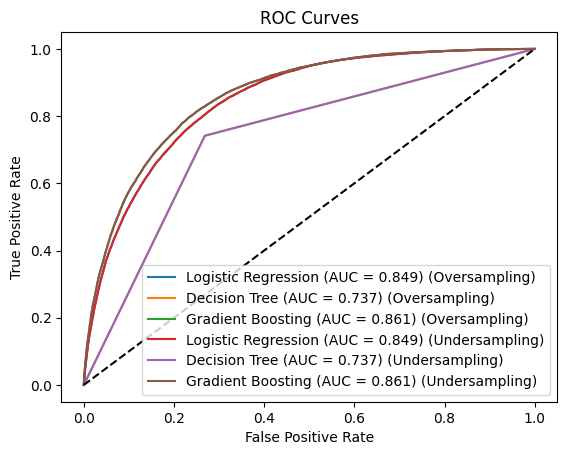

In [74]:
plt.figure()

for name, pipe in pipelines_over.items():

    y_proba = pipe.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f}) (Oversampling)")

for name, pipe in pipelines_under.items():

    y_proba = pipe.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f}) (Undersampling)")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

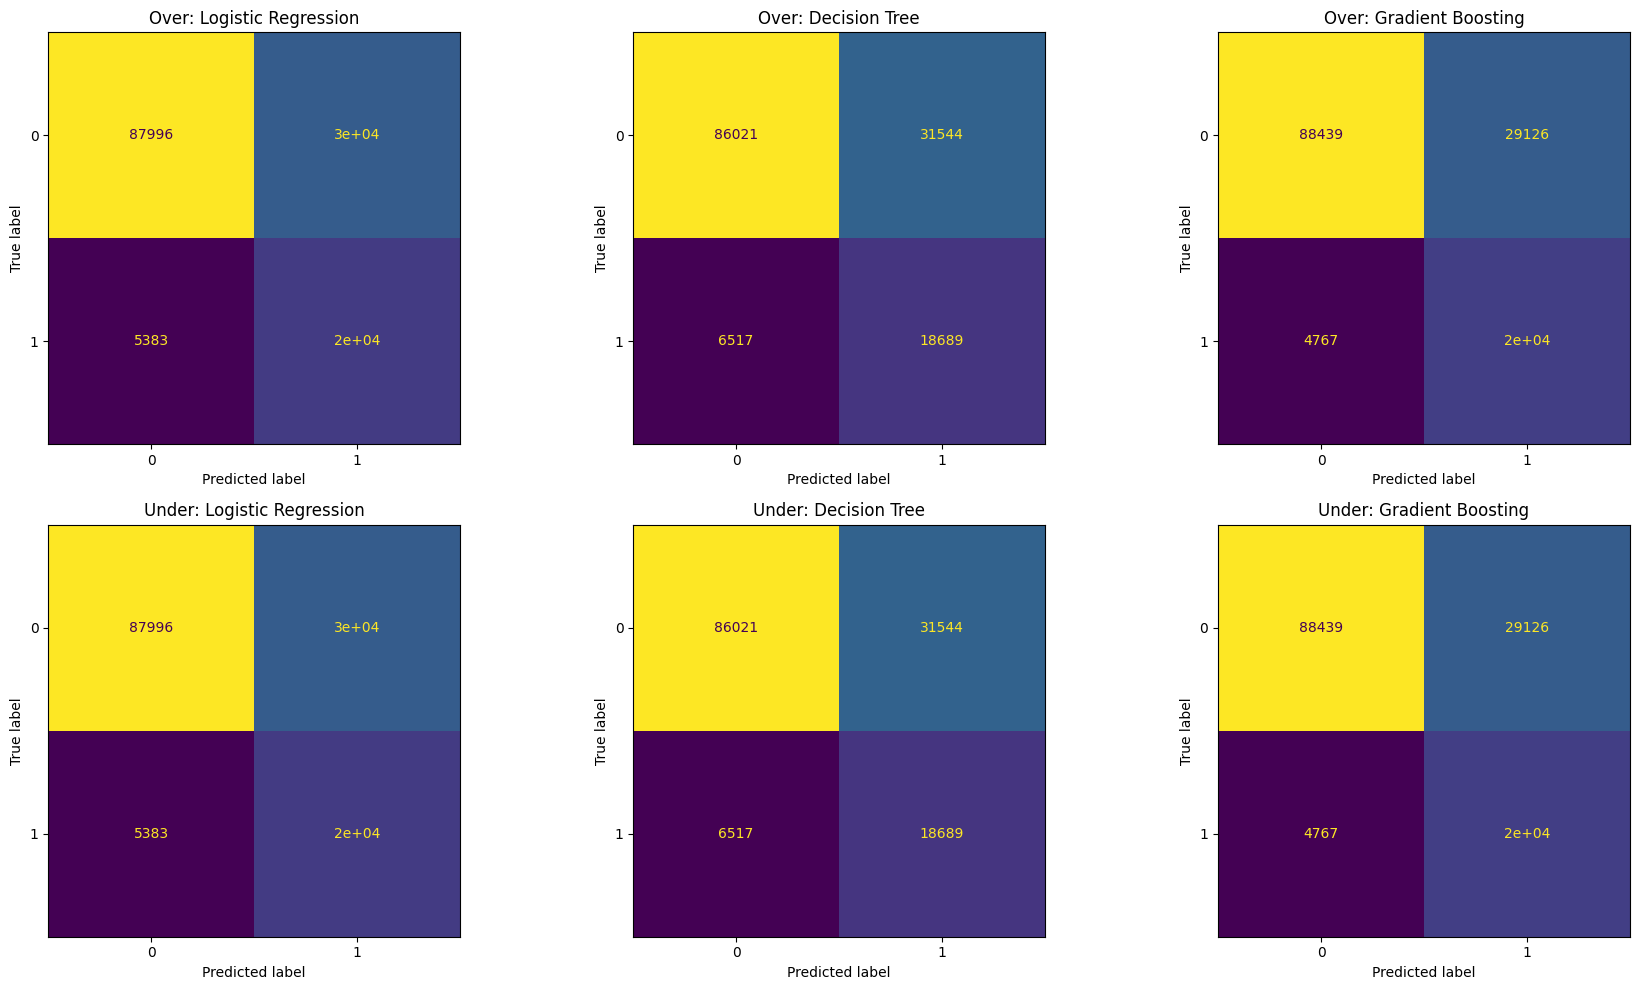

In [75]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10)) 

# Flatten axes for convenience (optional)
axes = axes.flatten()

# Plot over-sampling models
for i, (name, model) in enumerate(pipelines_over.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(f"Over: {name}")

# Plot under-sampling models
offset = len(pipelines_over)
for i, (name, model) in enumerate(pipelines_under.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i + offset], colorbar=False)
    axes[i + offset].set_title(f"Under: {name}")

# Hide any unused axes if you have less than 6 models total
for ax in axes[len(pipelines_over) + len(pipelines_under):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [76]:
df_main_avec_trajet = df_main.dropna(subset=['trajet'])